# Vibration-Based Machine Fault Classification

**Detecting and classifying rolling-bearing faults from accelerometer signals**

| | |
|---|---|
| **Author** | Mauricio Hernández |
| **Dataset** | Case Western Reserve University (CWRU) Bearing Data Center |
| **Task** | Multi-class classification (4 classes) |
| **Tools** | Python, NumPy, SciPy, pandas, scikit-learn, XGBoost, Matplotlib |
| **Primary metric** | Macro F1-score |

## Executive summary

**Objective.** Build a pipeline that takes a raw vibration signal from an industrial motor and determines whether its bearing is healthy or which component is damaged. This is the core task behind predictive maintenance: detecting a fault from sensor data before it causes an unplanned shutdown.

**Approach.** 40 accelerometer recordings were segmented into 2,331 short windows. From each window, 29 time-domain and frequency-domain features were extracted. Five classifiers were then benchmarked against a baseline under three evaluation designs of increasing difficulty.

**Key results (macro F1).**

| Evaluation design | What it tests | Best model | Macro F1 |
|---|---|---|---|
| A. Random split | Windows from recordings already seen | Several models | 1.00 |
| B. Unseen motor load | A new operating condition | Random Forest | 1.00 |
| C. Unseen fault severity | A fault size never seen in training | Logistic Regression | 0.78 |

**Main findings.**
1. On the standard random split every model scores close to 1.00. This result is optimistic because windows from the same recording appear in both training and test data.
2. When the model must recognize a fault at a severity it was never trained on, performance drops to 0.57 to 0.78. The simplest model, Logistic Regression, generalizes best; Random Forest and XGBoost overfit to the fault sizes they saw.
3. Separating healthy from faulty bearings remains reliable even in the hardest test. Identifying *which* component is damaged, especially the inner race, is the main source of error.

**Conclusion.** The choice of evaluation design changes which model looks best. For a real predictive-maintenance system, the test set must reflect conditions the model will face in operation.

## Contents

1. Background
2. Data
3. Signal exploration
4. Pre-processing: windowing and feature extraction
5. Modelling setup
6. Evaluation designs and results
7. Error analysis
8. Conclusions, limitations and next steps
9. Glossary
10. References

---
## 1. Background

### 1.1 Predictive maintenance
Industrial equipment is maintained in one of three ways:

| Strategy | Description | Main drawback |
|---|---|---|
| Reactive | Repair the machine after it fails | Unplanned downtime and the highest cost |
| Preventive | Service it on a fixed schedule | Parts are often replaced while still healthy |
| **Predictive** | Monitor its condition with sensors and intervene only when a fault is detected | Requires data and reliable models |

This notebook addresses the modelling side of predictive maintenance: turning sensor data into a fault diagnosis.

### 1.2 Rolling bearings
A rolling bearing lets a shaft rotate with low friction. It has four parts: an **inner race** (ring fixed to the shaft), an **outer race** (ring fixed to the housing), the **balls** that roll between them, and a cage that keeps the balls spaced. Bearing failures are one of the most common causes of motor breakdowns.

### 1.3 Why vibration reveals faults
When a ball rolls over a defect, it produces a short mechanical impact. Because the shaft rotates at a constant speed, these impacts repeat at a regular rate that depends on the damaged component. An accelerometer mounted on the motor records these impacts as sharp spikes in the vibration signal. A healthy bearing produces a smooth, low-amplitude signal without them.

The rest of this notebook measures those differences and teaches models to recognize them.

---
## 2. Data

### 2.1 Experimental setup
The CWRU test rig consists of a 2 hp electric motor with an accelerometer mounted on the drive-end bearing. Single-point defects were introduced on purpose using electro-discharge machining.

| Factor | Levels used in this notebook |
|---|---|
| Bearing condition | Normal, Ball fault, Inner race fault, Outer race fault (load zone, 6 o'clock) |
| Fault diameter | 0.007", 0.014", 0.021" |
| Motor load | 0, 1, 2, 3 hp (about 1,797 to 1,730 RPM) |
| Sensor | Drive-end accelerometer |
| Sampling rate | 12 kHz for fault recordings; 48 kHz for normal recordings (downsampled to 12 kHz) |
| Duration | About 10 seconds per recording |

**Scope decisions.**
- The 0.028" fault size is excluded because it does not exist for all fault types.
- For the outer race, only the 6 o'clock position is used, because it is the only position available for all three fault sizes.

### 2.2 Libraries and plotting style

In [1]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import decimate
from scipy.stats import kurtosis, skew
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
RANDOM_STATE = 42  # fixed seed so every result in this notebook is reproducible

# Plotting style shared by all charts
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.8,
    'axes.axisbelow': True,
    'axes.edgecolor': '#9a9993', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.titleweight': 'bold', 'axes.titlesize': 12, 'font.size': 10,
})

# One fixed colour per class, used consistently in every chart
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
GRAY, LIGHT_GRAY = '#8a8983', '#c9c8c2'
CLASSES = ['Normal', 'Ball', 'Inner race', 'Outer race']
COLORS = dict(zip(CLASSES, [BLUE, ORANGE, AQUA, YELLOW]))

### 2.3 Loading the recordings
Each `.mat` file contains several signals. Only the drive-end accelerometer channel (`*_DE_time`) is used.

The normal recordings were sampled at 48 kHz, four times faster than the fault recordings. They are downsampled by a factor of 4 with `scipy.signal.decimate`, which applies an anti-aliasing low-pass filter before removing samples. This keeps all signals on the same time and frequency scale.

**Data location.** The original files come from the [CWRU Bearing Data Center](https://engineering.case.edu/bearingdatacenter). They are also mirrored on GitHub in [XiongMeijing/CWRU-1](https://github.com/XiongMeijing/CWRU-1). Clone that repository next to this notebook before running it:

```
git clone https://github.com/XiongMeijing/CWRU-1.git
```

In [2]:
DATA_DIR = 'CWRU-1/Data'   # contains the 'Normal' and '12k_DE' sub-folders
FS = 12000                 # sampling rate after downsampling (samples per second)


def read_de_signal(path, record_number=None):
    # Return the drive-end accelerometer signal stored in a CWRU .mat file as a 1-D array.
    mat = sio.loadmat(path)
    keys = [k for k in mat if k.endswith('_DE_time')]
    if record_number is not None:   # some normal files store two records; keep the requested one
        keys = [k for k in keys if k.startswith(f'X{record_number:03d}')]
    return mat[keys[0]].ravel()


recordings = []

# Normal condition: records 97 to 100 correspond to motor loads 0 to 3 (48 kHz -> 12 kHz)
for load in range(4):
    x = read_de_signal(f'{DATA_DIR}/Normal/Normal_{load}.mat', record_number=97 + load)
    recordings.append(dict(label='Normal', size='none', load=load, signal=decimate(x, 4)))

# Fault conditions: file names follow the pattern <type><size>[@position]_<load>.mat, e.g. IR014_2.mat
fault_names = {'B': 'Ball', 'IR': 'Inner race', 'OR': 'Outer race'}
for fname in sorted(os.listdir(f'{DATA_DIR}/12k_DE')):
    m = re.match(r'(B|IR|OR)(\d{3})(@6)?_(\d)\.mat', fname)
    if not m:
        continue
    kind, size, at6, load = m.groups()
    if kind == 'OR' and at6 is None:   # outer race: keep the 6 o'clock position only
        continue
    if size == '028':                  # not available for every fault type
        continue
    recordings.append(dict(label=fault_names[kind], size=size, load=int(load),
                           signal=read_de_signal(f'{DATA_DIR}/12k_DE/{fname}')))

rec = pd.DataFrame(recordings)
rec['seconds'] = rec['signal'].apply(len) / FS

print(f'{len(rec)} recordings loaded')
rec.groupby('label').agg(recordings=('load', 'size'), total_seconds=('seconds', 'sum')).round(1)

40 recordings loaded


,recordings,total_seconds
label,,
Ball,12,121.9
Inner race,12,121.9
Normal,4,35.4
Outer race,12,122.1


**Interpretation.**
- The dataset contains 40 recordings: 12 per fault type (3 sizes x 4 loads) and 4 normal recordings (1 per load).
- The normal class has about 35 seconds of signal, against about 122 seconds for each fault type. The classes are therefore **imbalanced**. This is addressed later with balanced class weights and the macro F1 metric.

---
## 3. Signal exploration

### 3.1 Time domain
The chart shows the first 0.1 seconds of one recording per class (motor load 0, fault size 0.007"). All panels share the same vertical scale so that amplitudes can be compared directly.

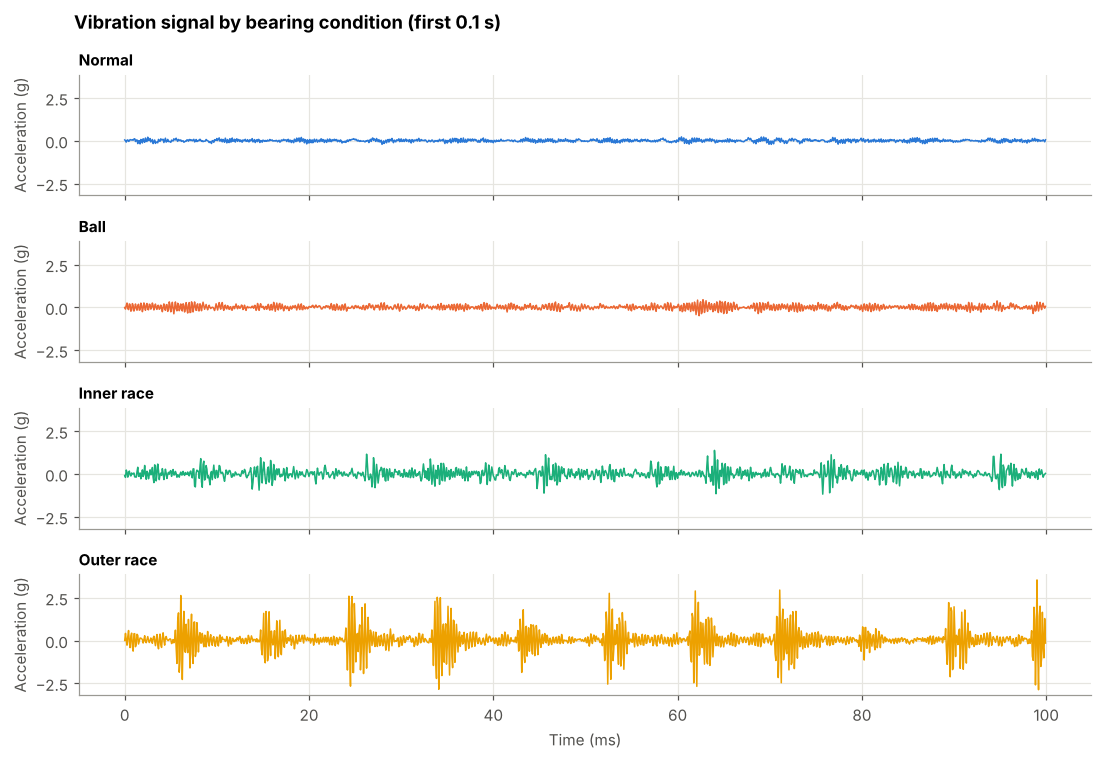

In [3]:
sample = rec[(rec['load'] == 0) & (rec['size'].isin(['none', '007']))].set_index('label')
n = int(0.1 * FS)                 # 0.1 s = 1,200 samples
t = np.arange(n) / FS * 1000      # time axis in milliseconds

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True, sharey=True)
for ax, cls in zip(axes, CLASSES):
    ax.plot(t, sample.loc[cls, 'signal'][:n], color=COLORS[cls], lw=1)
    ax.set_title(cls, loc='left', fontsize=10)
    ax.set_ylabel('Acceleration (g)')
axes[-1].set_xlabel('Time (ms)')
fig.suptitle('Vibration signal by bearing condition (first 0.1 s)', fontweight='bold', x=0.06, ha='left')
plt.tight_layout()
plt.show()

**Interpretation.**
- **Normal:** a smooth, low-amplitude signal with no visible impacts.
- **Outer race:** large spikes repeating at a regular interval, one for each ball passing over the defect.
- **Inner race:** smaller but frequent spikes. Their amplitude varies because the defect rotates with the shaft and moves in and out of the load zone.
- **Ball:** only slightly different from normal. This class is the hardest to identify visually.

### 3.2 Frequency domain
The **Fast Fourier Transform (FFT)** decomposes a signal into the frequencies it contains. The chart shows the spectrum of one second of signal per class, normalized so that each panel's highest peak equals 1. A Hanning window is applied before the FFT to reduce distortion at the edges of the segment.

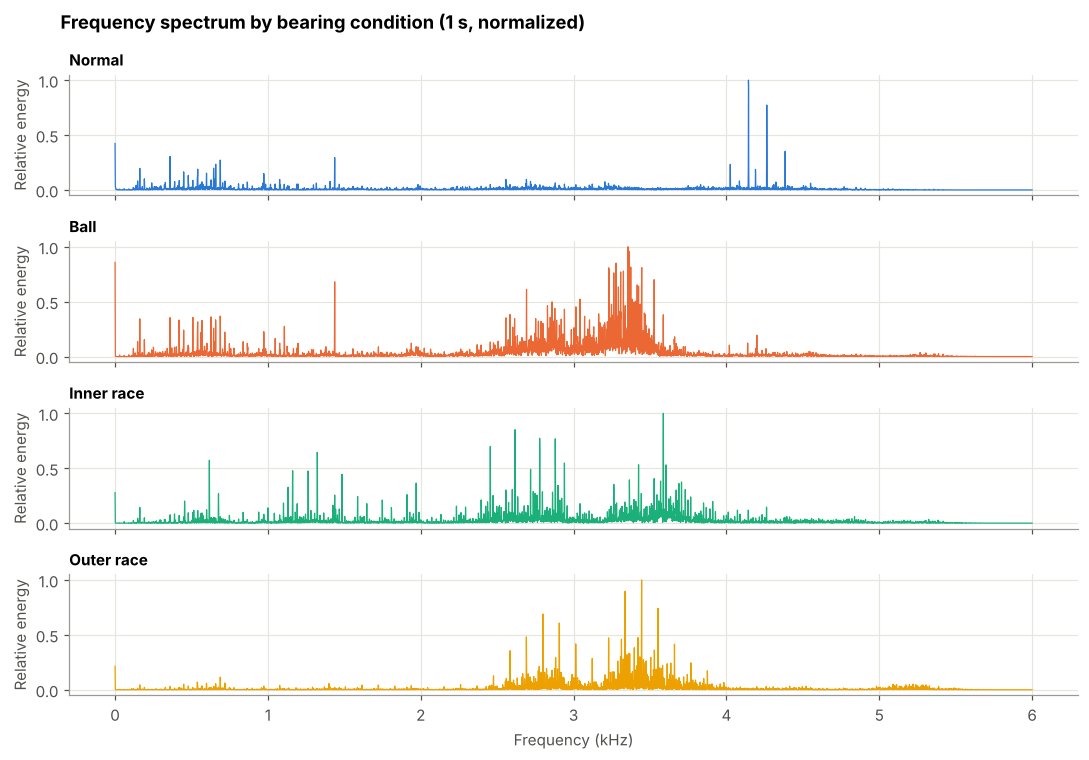

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
for ax, cls in zip(axes, CLASSES):
    x = sample.loc[cls, 'signal'][:FS]                     # 1 second of signal
    spectrum = np.abs(np.fft.rfft(x * np.hanning(len(x))))
    freq = np.fft.rfftfreq(len(x), 1 / FS)
    ax.plot(freq / 1000, spectrum / spectrum.max(), color=COLORS[cls], lw=0.8)
    ax.set_title(cls, loc='left', fontsize=10)
    ax.set_ylabel('Relative energy')
axes[-1].set_xlabel('Frequency (kHz)')
fig.suptitle('Frequency spectrum by bearing condition (1 s, normalized)', fontweight='bold', x=0.06, ha='left')
plt.tight_layout()
plt.show()

**Interpretation.**
- **Normal:** energy is concentrated in a few narrow peaks, at low frequencies (shaft rotation) and around 4.2 kHz.
- **Faults:** each impact excites the natural resonances of the machine structure, producing a **broad band of energy between about 2.5 and 3.7 kHz** that the healthy bearing does not show.
- **Inner race:** also carries additional energy between about 0.5 and 1.5 kHz.
- Because each condition distributes its energy differently across the spectrum, the share of energy in each frequency band is a useful input for the models.

---
## 4. Pre-processing: windowing and feature extraction

### 4.1 Windowing
A 10-second recording is a single long sequence, while a model needs many labelled examples. Each recording is therefore split into **non-overlapping windows of 2,048 samples** (about 0.17 s, roughly five shaft revolutions). Each window becomes one row of the modelling dataset and inherits the label, fault size and motor load of its recording.

### 4.2 Feature extraction
Each window is summarized by 29 numerical features in three groups:

| Group | Features | What they measure |
|---|---|---|
| Amplitude | Mean, standard deviation, RMS, peak, peak-to-peak | Overall vibration intensity |
| Shape | Kurtosis, skewness, crest factor, shape factor, impulse factor, clearance factor | How impulsive or "spiky" the signal is |
| Frequency | Share of energy in 16 bands of 375 Hz (0 to 6 kHz), spectral centroid, dominant frequency | Where the energy sits in the spectrum |

The frequency-band features are expressed as a **share of total energy**, so they describe the shape of the spectrum independently of how strong the vibration is.

In [5]:
WINDOW = 2048
BAND_EDGES = np.linspace(0, FS / 2, 17)   # 16 equal bands from 0 to 6,000 Hz


def extract_features(w):
    # Compute 29 time- and frequency-domain features for one signal window.
    rms = np.sqrt(np.mean(w ** 2))
    peak = np.max(np.abs(w))
    mean_abs = np.mean(np.abs(w))

    features = {
        # Amplitude
        'mean': w.mean(), 'std': w.std(), 'rms': rms, 'peak': peak, 'p2p': w.max() - w.min(),
        # Shape
        'kurtosis': kurtosis(w), 'skewness': skew(w),
        'crest': peak / rms,
        'shape': rms / mean_abs,
        'impulse': peak / mean_abs,
        'clearance': peak / np.mean(np.sqrt(np.abs(w))) ** 2,
    }

    # Frequency: power spectrum of the windowed signal
    power = np.abs(np.fft.rfft(w * np.hanning(len(w)))) ** 2
    freq = np.fft.rfftfreq(len(w), 1 / FS)
    total = power.sum()
    for i in range(16):
        in_band = (freq >= BAND_EDGES[i]) & (freq < BAND_EDGES[i + 1])
        features[f'band_{i:02d}'] = power[in_band].sum() / total
    features['spec_centroid'] = (freq * power).sum() / total
    features['dom_freq'] = freq[np.argmax(power[1:]) + 1]   # ignore the 0 Hz component
    return features


rows = []
for _, r in rec.iterrows():
    x = r['signal']
    for i in range(len(x) // WINDOW):
        f = extract_features(x[i * WINDOW:(i + 1) * WINDOW])
        f.update(label=r['label'], size=r['size'], load=r['load'])
        rows.append(f)

df = pd.DataFrame(rows)
FEATURES = [c for c in df.columns if c not in ('label', 'size', 'load')]

print(f'Modelling dataset: {df.shape[0]:,} windows x {len(FEATURES)} features')
df['label'].value_counts().rename('windows').to_frame()

Modelling dataset: 2,331 windows x 29 features


,windows
label,
Inner race,709
Ball,708
Outer race,708
Normal,206


**Interpretation.** The 40 recordings produce 2,331 windows: about 708 per fault type and 206 for the normal condition. The modelling dataset is now a standard table, one row per window and one column per feature.

### 4.3 Single-feature check: kurtosis
Before modelling, it is useful to check whether a single feature already separates the classes. **Kurtosis** measures how impulsive a signal is: values near 0 indicate a smooth signal, while high values indicate sharp, isolated spikes.

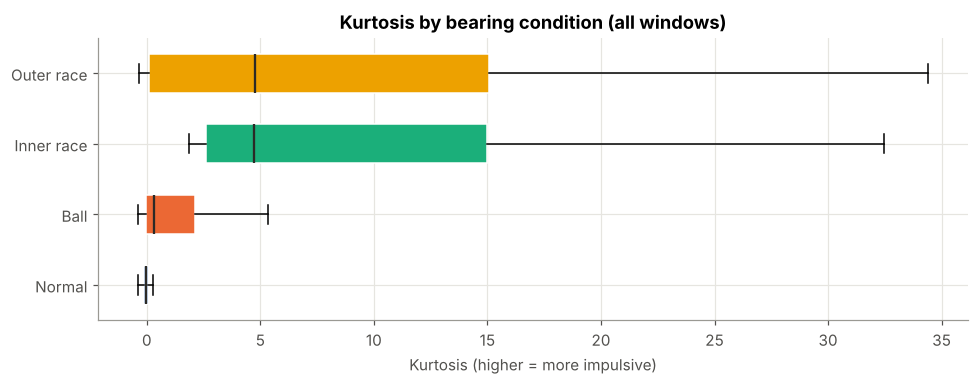

,25%,50%,75%
label,,,
Ball,-0.03,0.30,2.14
Inner race,2.61,4.73,14.99
Normal,-0.13,-0.03,0.05
Outer race,0.09,4.75,15.05


In [6]:
fig, ax = plt.subplots(figsize=(9, 3.6))
data = [df.loc[df['label'] == c, 'kurtosis'] for c in CLASSES]
bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.55, showfliers=False,
                medianprops=dict(color='#2b2a27', lw=1.5))
for patch, c in zip(bp['boxes'], CLASSES):
    patch.set_facecolor(COLORS[c])
    patch.set_edgecolor('white')
ax.set_yticks(range(1, 5), CLASSES)
ax.set(title='Kurtosis by bearing condition (all windows)', xlabel='Kurtosis (higher = more impulsive)')
plt.tight_layout()
plt.show()

df.groupby('label')['kurtosis'].describe()[['25%', '50%', '75%']].round(2)

**Interpretation.**
- Inner and outer race faults are far more impulsive than the normal condition (median kurtosis of about 5, against about 0).
- The ball fault is only slightly more impulsive than normal.
- The inner and outer race distributions overlap almost completely, so kurtosis alone cannot distinguish them. A model that combines all 29 features is required.

---
## 5. Modelling setup

### 5.1 Candidate models

| Model | Type | Why it is included |
|---|---|---|
| Baseline (most frequent class) | Reference | Lower bound; any useful model must beat it |
| Logistic Regression | Linear | Simple, interpretable, less prone to overfitting |
| K-Nearest Neighbours (k = 5) | Instance-based | Classifies by similarity to known examples |
| Support Vector Machine (RBF kernel) | Kernel-based | Captures non-linear boundaries |
| Random Forest | Tree ensemble (bagging) | Strong general-purpose model for tabular data |
| XGBoost | Tree ensemble (boosting) | Frequently the top performer on tabular benchmarks |

### 5.2 Design decisions
- **Scaling.** Logistic Regression, KNN and SVM are sensitive to feature scale, so their features are standardized (mean 0, standard deviation 1). The scaler is placed inside a `Pipeline`, which fits it on the training data only and prevents information from the test set leaking into training.
- **Class imbalance.** `class_weight='balanced'` increases the weight of the smaller normal class during training.
- **Metric.** **Macro F1** averages the F1-score of the four classes with equal weight, so poor performance on any class, including the smaller normal class, lowers the score. Accuracy is also reported for reference.
- **Fresh models per experiment.** Models are created inside a function so that every fold starts from an untrained model.

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

encoder = LabelEncoder().fit(CLASSES)
X = df[FEATURES].values
y = encoder.transform(df['label'])


def get_models():
    # Return a dictionary of untrained models.
    return {
        'Baseline (most frequent)': DummyClassifier(strategy='most_frequent'),
        'Logistic Regression': make_pipeline(StandardScaler(),
                                             LogisticRegression(max_iter=3000, class_weight='balanced')),
        'KNN (k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
        'SVM (RBF)': make_pipeline(StandardScaler(), SVC(C=10, class_weight='balanced')),
        'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                                 random_state=RANDOM_STATE, n_jobs=-1),
    }


def evaluate(folds):
    # Train and test every model on each (train_mask, test_mask) fold.
    # Returns mean accuracy and macro F1 per model, plus pooled test predictions for error analysis.
    scores, predictions = {}, {}
    for name in get_models():
        acc, f1, y_true, y_pred = [], [], [], []
        for train_mask, test_mask in folds:
            model = get_models()[name]
            model.fit(X[train_mask], y[train_mask])
            p = model.predict(X[test_mask])
            acc.append(accuracy_score(y[test_mask], p))
            f1.append(f1_score(y[test_mask], p, average='macro'))
            y_true += list(y[test_mask])
            y_pred += list(p)
        scores[name] = dict(accuracy=np.mean(acc), macro_f1=np.mean(f1), f1_per_fold=np.round(f1, 3))
        predictions[name] = (np.array(y_true), np.array(y_pred))
    return pd.DataFrame(scores).T, predictions

---
## 6. Evaluation designs and results

A model is only as trustworthy as the test used to evaluate it. Three designs are compared, from the most common to the most realistic:

| Design | Training data | Test data | Question it answers |
|---|---|---|---|
| A. Random split | Random 80% of windows | Remaining 20% | Can the model classify more windows from recordings it has already seen? |
| B. Leave-one-load-out | 3 motor loads | The 4th load (repeated 4 times) | Does the model work at an operating condition it has not seen? |
| C. Leave-one-severity-out | 2 fault sizes | The 3rd size (repeated 3 times) | Can the model recognize a fault type at a severity it has not seen? |

### 6.1 Design A: random split
Windows are shuffled and split 80/20, stratified by class.

**Limitation.** Consecutive windows from the same recording are nearly identical, and this split places windows from every recording in both the training and test sets. The model is therefore tested on data very similar to what it was trained on, which makes this result optimistic. It is included because it is the most common approach in published examples.

In [8]:
idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.2, stratify=y,
                                       random_state=RANDOM_STATE)
train_mask = np.zeros(len(df), dtype=bool)
train_mask[idx_train] = True

results_random, _ = evaluate([(train_mask, ~train_mask)])
results_random.round(3)

,accuracy,macro_f1,f1_per_fold
Baseline (most frequent),0.304069,0.116585,[0.117]
Logistic Regression,1.0,1.0,[1.0]
KNN (k=5),1.0,1.0,[1.0]
SVM (RBF),1.0,1.0,[1.0]
Random Forest,1.0,1.0,[1.0]
XGBoost,0.997859,0.998239,[0.998]


**Interpretation.** Every model except the baseline reaches a macro F1 of 1.00 or very close to it. On its own, this would suggest the problem is solved.

### 6.2 Design B: unseen motor load
Each fold trains on three motor loads and tests on the fourth. The reported score is the average over the four folds.

In [9]:
folds_load = [((df['load'] != L).values, (df['load'] == L).values) for L in range(4)]
results_load, _ = evaluate(folds_load)
results_load.round(3)

,accuracy,macro_f1,f1_per_fold
Baseline (most frequent),0.303891,0.116521,"[0.12, 0.115, 0.115, 0.115]"
Logistic Regression,0.986607,0.972939,"[0.892, 1.0, 1.0, 1.0]"
KNN (k=5),0.983482,0.968758,"[0.875, 1.0, 1.0, 1.0]"
SVM (RBF),0.964732,0.969696,"[0.879, 1.0, 1.0, 1.0]"
Random Forest,1.0,1.0,"[1.0, 1.0, 1.0, 1.0]"
XGBoost,0.969431,0.975059,"[0.914, 1.0, 1.0, 0.986]"


**Interpretation.** Performance remains high (0.97 to 1.00). Changing the motor load alters the vibration only slightly, and the same physical bearings and fault sizes appear in both training and test data. This design is harder than A, but still optimistic.

### 6.3 Design C: unseen fault severity
Each fold holds out one fault size entirely: the model is trained on the other two sizes and tested on the held-out one. To keep the normal class in the test set, each fold also holds out one normal recording (a different motor load in each fold).

This is the most realistic design. In operation, a fault starts small and grows over time, so a model must recognize a fault type at severities it was not trained on.

In [10]:
SIZES = ['007', '014', '021']
folds_size = []
for k, size in enumerate(SIZES):
    test_mask = ((df['size'] == size) | ((df['label'] == 'Normal') & (df['load'] == k))).values
    folds_size.append((~test_mask, test_mask))

results_size, predictions_size = evaluate(folds_size)
results_size.round(3)

,accuracy,macro_f1,f1_per_fold
Baseline (most frequent),0.311723,0.118815,"[0.121, 0.118, 0.118]"
Logistic Regression,0.767024,0.78139,"[0.998, 0.692, 0.654]"
KNN (k=5),0.658302,0.63698,"[0.691, 0.587, 0.633]"
SVM (RBF),0.552574,0.565363,"[0.696, 0.438, 0.562]"
Random Forest,0.584094,0.588813,"[1.0, 0.372, 0.394]"
XGBoost,0.585278,0.580851,"[0.993, 0.374, 0.376]"


**Interpretation.**
- Scores drop sharply for every model, and the ranking changes.
- **Logistic Regression** generalizes best, with a mean macro F1 of 0.78.
- **Random Forest and XGBoost** fall to about 0.58. In the first fold (unseen 0.007" faults) they score close to 1.00, but on the 0.014" and 0.021" folds they drop below 0.40. Tree models learn precise thresholds tied to the fault sizes in the training data, and those thresholds do not transfer to a new size.

### 6.4 Comparison across designs

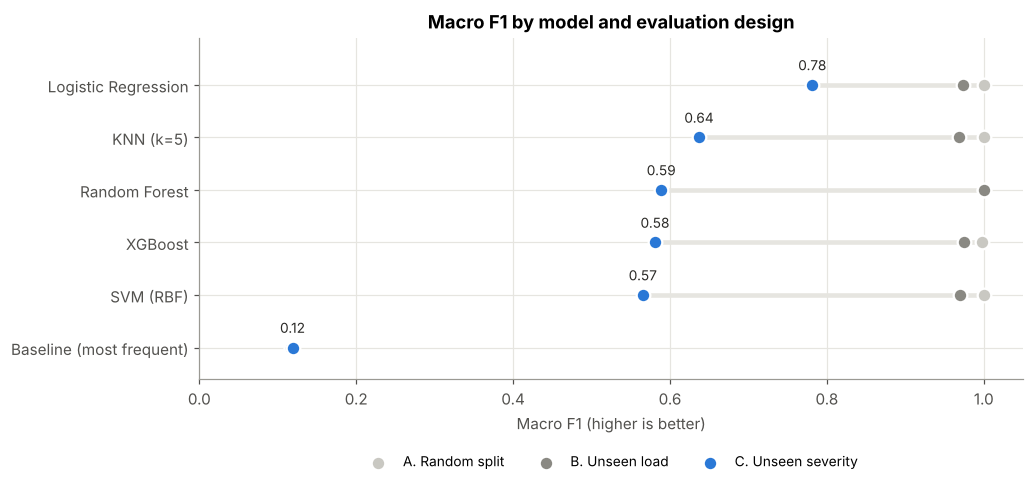

,A. Random split,B. Unseen load,C. Unseen severity
Baseline (most frequent),0.117,0.117,0.119
Logistic Regression,1.000,0.973,0.781
KNN (k=5),1.000,0.969,0.637
SVM (RBF),1.000,0.970,0.565
Random Forest,1.000,1.000,0.589
XGBoost,0.998,0.975,0.581


In [11]:
summary = pd.DataFrame({
    'A. Random split': results_random['macro_f1'],
    'B. Unseen load': results_load['macro_f1'],
    'C. Unseen severity': results_size['macro_f1'],
}).astype(float)

order = summary.sort_values('C. Unseen severity').index   # best model on the hardest test at the top
design_colors = {'A. Random split': LIGHT_GRAY, 'B. Unseen load': GRAY, 'C. Unseen severity': BLUE}

fig, ax = plt.subplots(figsize=(9.5, 4.6))
pos = np.arange(len(order))
ax.hlines(pos, summary.loc[order].min(axis=1), summary.loc[order].max(axis=1), color='#e6e5e0', lw=3)
for col, c in design_colors.items():
    ax.scatter(summary.loc[order, col], pos, s=80, color=c, zorder=3, edgecolor='white', lw=1.5, label=col)
for i, v in enumerate(summary.loc[order, 'C. Unseen severity']):
    ax.text(v, i + 0.28, f'{v:.2f}', ha='center', fontsize=9, color='#2b2a27')
ax.set_yticks(pos, order)
ax.set_xlim(0, 1.05)
ax.set_ylim(-0.6, len(order) - 0.1)
ax.set(title='Macro F1 by model and evaluation design', xlabel='Macro F1 (higher is better)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

summary.round(3)

**Interpretation.**
- Under designs A and B, all five models look nearly equivalent and nearly perfect.
- Design C separates them clearly. Design B alone would have favoured Random Forest (1.00), which ranks only third under Design C.
- **Model selection: Logistic Regression**, because it performs best under the condition that most resembles real operation.

---
## 7. Error analysis

The confusion matrix below pools the test predictions of the three Design C folds for the selected model. Each row shows how the windows of one actual class were classified, as a percentage of that class.

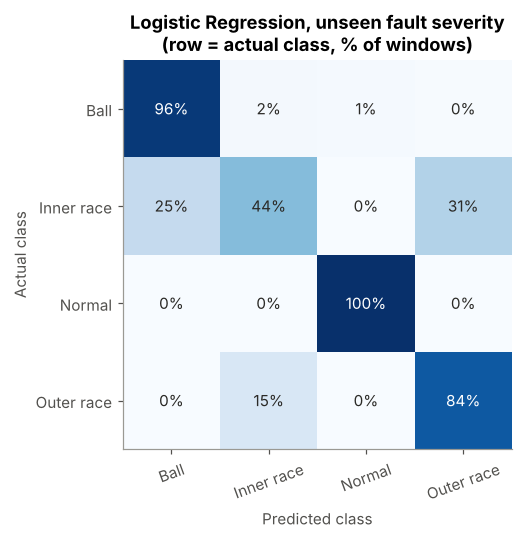

              precision    recall  f1-score   support

        Ball      0.789     0.963     0.868       708
  Inner race      0.716     0.437     0.543       709
      Normal      0.942     1.000     0.970       147
  Outer race      0.729     0.843     0.782       708

    accuracy                          0.764      2272
   macro avg      0.794     0.811     0.791      2272
weighted avg      0.758     0.764     0.746      2272



In [12]:
best = 'Logistic Regression'
y_true, y_pred = predictions_size[best]
cm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
ax.grid(False)
ax.set_xticks(range(4), encoder.classes_, rotation=20)
ax.set_yticks(range(4), encoder.classes_)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{cm[i, j]:.0%}', ha='center', va='center',
                color='white' if cm[i, j] > 0.55 else '#2b2a27', fontsize=10)
ax.set(title=f'{best}, unseen fault severity\n(row = actual class, % of windows)',
       xlabel='Predicted class', ylabel='Actual class')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=encoder.classes_, digits=3))

**Interpretation.**
- **Fault detection is reliable.** All normal windows are classified as normal, and fewer than 1% of fault windows are mistaken for normal. A system built on this model would rarely miss a fault or raise a false alarm on a healthy machine.
- **Fault identification is the weak point.** At an unseen severity, only 44% of inner race windows are correctly identified; 31% are labelled as outer race and 25% as ball faults.
- **Practical implication.** The model is already useful as an early-warning detector. Telling the maintenance team *which* component to inspect requires further work.

---
## 8. Conclusions, limitations and next steps

### 8.1 Conclusions
1. A pipeline of windowing, 29 time- and frequency-domain features and a standard classifier can detect and classify bearing faults from raw vibration data.
2. Results depend heavily on the evaluation design. Random and leave-one-load-out splits produce near-perfect scores for every model; a leave-one-severity-out split reveals large differences between them.
3. Under the most realistic design, Logistic Regression (macro F1 0.78) generalizes better than Random Forest and XGBoost (about 0.58), which overfit to the fault sizes seen in training.
4. Distinguishing healthy from faulty bearings is reliable; identifying the damaged component at a new severity remains difficult, particularly for inner race faults.

### 8.2 Limitations
- **Laboratory data.** All faults were introduced artificially on a single test rig. Real faults develop gradually and occur alongside other sources of vibration and noise.
- **Small number of physical conditions.** Although there are 2,331 windows, they come from only 40 recordings, so the effective sample size is much smaller than the row count suggests.
- **Unequal sampling for the normal class.** Normal recordings were downsampled from 48 kHz, while fault recordings were captured at 12 kHz. This could introduce small differences unrelated to bearing condition.
- **No hyperparameter tuning.** Models use reasonable default settings. Tuning could improve scores but would require a separate validation scheme to avoid overfitting the test folds.

### 8.3 Next steps
1. **Envelope analysis.** Demodulate the high-frequency resonance band to extract the characteristic fault frequencies (BPFI, BPFO, BSF), a standard technique in bearing diagnostics that is less dependent on fault size.
2. **Deep learning.** Train a one-dimensional convolutional neural network on the raw windows and compare it with the feature-based models under the same three evaluation designs.
3. **Transfer to a new machine.** Apply the pipeline to vibration data from a different test rig, such as a machinery fault simulator, to measure how well it generalizes beyond the CWRU setup.

---
## 9. Glossary

| Term | Definition |
|---|---|
| Accelerometer | Sensor that measures vibration as acceleration, in units of g |
| Bearing race | The inner or outer ring of a rolling bearing |
| Window | A short, fixed-length segment of a longer signal, used as one training example |
| RMS (root mean square) | Measure of overall vibration energy |
| Kurtosis | Measure of how impulsive a signal is; high values indicate sharp spikes |
| Crest factor | Ratio of the peak value to the RMS; high values indicate impacts |
| FFT (Fast Fourier Transform) | Algorithm that converts a time signal into its frequency components |
| Spectral centroid | The "centre of mass" of a spectrum; indicates whether energy is mostly at low or high frequencies |
| Data leakage | When information from the test set influences training, producing optimistic results |
| Macro F1 | Average of the per-class F1-scores, giving every class equal weight |
| Overfitting | When a model learns patterns specific to its training data that do not generalize to new data |

---
## 10. References

1. Case Western Reserve University Bearing Data Center. *Seeded fault test data.* https://engineering.case.edu/bearingdatacenter
2. Smith, W. A., and Randall, R. B. (2015). Rolling element bearing diagnostics using the Case Western Reserve University data: a benchmark study. *Mechanical Systems and Signal Processing*, 64-65, 100-131.
3. Randall, R. B., and Antoni, J. (2011). Rolling element bearing diagnostics: a tutorial. *Mechanical Systems and Signal Processing*, 25(2), 485-520.

### Environment

In [13]:
import sklearn, scipy, xgboost, matplotlib
for lib in [np, pd, scipy, sklearn, xgboost, matplotlib]:
    print(f'{lib.__name__:<12} {lib.__version__}')

numpy        2.5.3
pandas       3.0.5
scipy        1.18.1
sklearn      1.9.1
xgboost      3.4.1
matplotlib   3.11.2
